# 🎓 Federated Learning: De la Teoría a la Práctica
**Presentación Interactiva con Visualizaciones**

Este notebook demuestra visualmente la diferencia entre el aprendizaje local (fallido) y el federado (exitoso), además de explorar optimizaciones clave.

## Contenido
1.  **L1: El Fracaso Local** (Matriz de Confusión)
2.  **L2: El Éxito Federado** (Matriz de Confusión Global)
3.  **L3: Tuning Dinámico** (Simulación con Ajuste de Hiperparámetros)
4.  **L4: Privacidad** (Simulación con Adaptive Clipping)
5.  **L5: Ancho de Banda** (Cuantización y Comparativa de Tamaños)

### 0. Preparación del Entorno

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns
import json
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Importamos utilidades
from utils1 import plot_distribution, exclude_digits, SimpleModel, train_model, evaluate_model, compute_confusion_matrix, plot_confusion_matrix
from utils2 import set_weights, get_weights
from flwr.client import NumPyClient, ClientApp
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation
from flwr.common import ndarrays_to_parameters, Context
from flwr.client.mod import adaptiveclipping_mod

print("✅ Entorno listo.")

✅ Entorno listo.


--- 
## 1. L1: El Problema (Entrenamiento Local)
**Escenario:** Un cliente tiene datos sesgados. Nunca ha visto los números **1, 3, y 7**.
Vamos a entrenar un modelo solo con sus datos y ver qué pasa.

In [ ]:
# 1. Preparar datos sesgados
mnist_train = datasets.MNIST("./MNIST_data", train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST("./MNIST_data", train=False, download=True, transform=transforms.ToTensor())

# Dividimos en 3 partes para usar después
partition_size = len(mnist_train) // 3
part1 = torch.utils.data.Subset(mnist_train, range(0, partition_size))
part2 = torch.utils.data.Subset(mnist_train, range(partition_size, partition_size * 2))
part3 = torch.utils.data.Subset(mnist_train, range(partition_size * 2, partition_size * 3))

# Creamos 3 clientes con sesgos COMPLEMENTARIOS
# Cliente 1: No tiene 1, 3, 7
part1_biased = exclude_digits(part1, excluded_digits=[1, 3, 7])
# Cliente 2: No tiene 2, 5, 8
part2_biased = exclude_digits(part2, excluded_digits=[2, 5, 8])
# Cliente 3: No tiene 4, 6, 9
part3_biased = exclude_digits(part3, excluded_digits=[4, 6, 9])

# Visualizar el sesgo del Cliente 1
plot_distribution(part1_biased, "Distribución de Datos (Cliente 1)")
# Visualizar el sesgo del Cliente 2
plot_distribution(part2_biased, "Distribución de Datos (Cliente 2)")
# Visualizar el sesgo del Cliente 3
plot_distribution(part3_biased, "Distribución de Datos (Cliente 3)")

# 2. Entrenar y Evaluar Modelos Localmente (Para cada cliente)
clients_data = [
    ("Cliente 1 (Sin 1,3,7)", part1_biased),
    ("Cliente 2 (Sin 2,5,8)", part2_biased),
    ("Cliente 3 (Sin 4,6,9)", part3_biased)
]

for client_name, train_data in clients_data:
    print(f"\n🧠 Entrenando modelo local para {client_name}...")
    model = SimpleModel()
    train_model(model, train_data, epochs=1)
    
    print(f"📊 Generando Matriz de Confusión para {client_name}...")
    cm = compute_confusion_matrix(model, mnist_test)
    plot_confusion_matrix(cm, f"Matriz de Confusión - {client_name}")

print("\n🔴 Observa cómo cada modelo falla en los números que no ha visto.")

--- 
## 2. L2: La Solución (Entrenamiento Federado)

**Escenario:** Ahora, 3 clientes colaboran. Cada uno es ciego a ciertos números, pero **juntos** tienen todos.

*   **Rondas (Rounds):** Veces que el servidor mezcla los modelos (Global).
*   **Épocas (Epochs):** Veces que el cliente entrena con sus datos (Local).

Aquí haremos 3 Rondas Globales, y en cada una, los clientes entrenan 1 Época Local.

In [ ]:
# Archivo temporal para guardar métricas y modelo
METRICS_FILE = "metrics.json"
GLOBAL_MODEL_FILE = "global_model.pth"
PARTITION_COUNTER_FILE = "partition_counter.txt" # Archivo para coordinar la asignación de datos

if os.path.exists(METRICS_FILE):
    os.remove(METRICS_FILE)
if os.path.exists(GLOBAL_MODEL_FILE):
    os.remove(GLOBAL_MODEL_FILE)

# Función para obtener un ID de partición único y secuencial (0, 1, 2...)
# Esto asegura que SIEMPRE tengamos un cliente de cada tipo, sin importar la aleatoriedad de Ray
def get_next_partition_id():
    if not os.path.exists(PARTITION_COUNTER_FILE):
        with open(PARTITION_COUNTER_FILE, "w") as f:
            f.write("0")
    
    # Leemos y actualizamos el contador de forma atómica (o casi)
    try:
        with open(PARTITION_COUNTER_FILE, "r+") as f:
            content = f.read().strip()
            current_id = int(content) if content else 0
            f.seek(0)
            f.write(str(current_id + 1))
            f.truncate()
            return current_id
    except Exception:
        return 0 # Fallback por si hay condición de carrera (raro con 3 clientes)

# Definimos el Cliente
class DemoClient(NumPyClient):
    def __init__(self, net, trainset):
        self.net = net
        self.trainset = trainset

    def fit(self, parameters, config):
        set_weights(self.net, parameters)
        # Entrenamos 1 época localmente
        train_model(self.net, self.trainset, epochs=1)
        return get_weights(self.net), len(self.trainset), {}

    def evaluate(self, parameters, config):
        set_weights(self.net, parameters)
        loss, accuracy = evaluate_model(self.net, mnist_test)
        return loss, len(mnist_test), {"accuracy": accuracy}

def client_fn(context: Context):
    net = SimpleModel()
    
    # TRUCO: Usamos nuestro contador determinista en lugar del node_id aleatorio
    # partition_id = int(context.node_id) # Antes (Aleatorio)
    partition_id = get_next_partition_id() # Ahora (Secuencial: 0, 1, 2...)
    
    # Asignamos datos según el turno
    if partition_id % 3 == 0:
        data = part1_biased # Faltan 1, 3, 7
        print(f"  👤 Cliente {partition_id} (Tipo 1): Sin 1, 3, 7")
    elif partition_id % 3 == 1:
        data = part2_biased # Faltan 2, 5, 8
        print(f"  👤 Cliente {partition_id} (Tipo 2): Sin 2, 5, 8")
    else:
        data = part3_biased # Faltan 4, 6, 9
        print(f"  👤 Cliente {partition_id} (Tipo 3): Sin 4, 6, 9")
        
    return DemoClient(net, data).to_client()

# Estrategia con Evaluación en Servidor
def evaluate_server(server_round, parameters, config):
    try:
        net = SimpleModel()
        set_weights(net, parameters)
        loss, accuracy = evaluate_model(net, mnist_test)
        
        # Guardar el modelo global actual
        torch.save(net.state_dict(), GLOBAL_MODEL_FILE)
            
        return loss, {"accuracy": accuracy}
    except Exception as e:
        print(f"⚠️ Error en evaluación: {e}")
        return 0.0, {"accuracy": 0.0}

def server_fn(context: Context):
    net = SimpleModel()
    params = ndarrays_to_parameters(get_weights(net))
    strategy = FedAvg(
        initial_parameters=params,
        evaluate_fn=evaluate_server
    )
    return ServerAppComponents(strategy=strategy, config=ServerConfig(num_rounds=3))

# Reiniciamos el contador antes de empezar
with open(PARTITION_COUNTER_FILE, "w") as f:
    f.write("0")

print("🚀 Iniciando Federación con 3 Clientes (Asignación Determinista)...")
history = run_simulation(
    server_app=ServerApp(server_fn=server_fn),
    client_app=ClientApp(client_fn),
    num_supernodes=3, # ¡3 Clientes distintos!
    backend_config={"tensorflow": 0}
)

# Visualizar el Éxito con Matriz de Confusión
print("\n✅ Federación completada.")
if os.path.exists(GLOBAL_MODEL_FILE):
    print("📊 Generando Matriz de Confusión del Modelo Global Final...")
    final_model = SimpleModel()
    final_model.load_state_dict(torch.load(GLOBAL_MODEL_FILE))
    
    cm = compute_confusion_matrix(final_model, mnist_test)
    plot_confusion_matrix(cm, "Matriz de Confusión - Modelo Global Federado")
    print("🟢 ¡Éxito! El modelo global ha aprendido TODOS los números gracias a la colaboración.")
else:
    print("❌ No se encontró el modelo global guardado.")

--- 
## 3. L3: Tuning Dinámico (Simulación Real)

**Concepto:** El servidor puede ajustar los hiperparámetros (como `epochs` o `learning_rate`) en cada ronda para mejorar el entrenamiento. Aquí simulamos un aumento de épocas a partir de la ronda 2.

In [ ]:
# Definimos una función para configurar el entrenamiento dinámicamente
def fit_config(server_round: int):
    """Cambia la configuración según la ronda."""
    config = {
        "server_round": server_round,
        "local_epochs": 1 if server_round < 2 else 2, # Aumenta épocas en ronda 2
        "learning_rate": 1.0 if server_round < 2 else 0.5, # Reduce LR en ronda 2
    }
    return config

# Cliente que usa la config
class TuningClient(NumPyClient):
    def __init__(self, net, trainset):
        self.net = net
        self.trainset = trainset

    def fit(self, parameters, config):
        # Leemos la configuración enviada por el servidor
        epochs = config["local_epochs"]
        lr = config["learning_rate"]
        print(f"  🔄 [Cliente] Ronda {config['server_round']}: Entrenando {epochs} épocas con LR {lr}")
        
        set_weights(self.net, parameters)
        # Entrenamos con las épocas dinámicas
        train_model(self.net, self.trainset, epochs=epochs)
        return get_weights(self.net), len(self.trainset), {}

def tuning_client_fn(context: Context):
    net = SimpleModel()
    # Usamos el subset part1 para rapidez en esta demo
    return TuningClient(net, part1).to_client()

# Estrategia con fit_config
def server_fn_tuning(context: Context):
    strategy_tuning = FedAvg(
        initial_parameters=ndarrays_to_parameters(get_weights(SimpleModel())),
        on_fit_config_fn=fit_config
    )
    return ServerAppComponents(strategy=strategy_tuning, config=ServerConfig(num_rounds=3))

print("🚀 Iniciando Simulación L3 (Tuning Dinámico)...")
run_simulation(
    server_app=ServerApp(server_fn=server_fn_tuning),
    client_app=ClientApp(tuning_client_fn),
    num_supernodes=2,
    backend_config={"tensorflow": 0}
)
print("✅ Simulación L3 completada. Observa los logs arriba para ver el cambio de configuración en Ronda 2.")

--- 
## 4. L4: Privacidad Diferencial (Simulación Real)

**Concepto:** Protegemos la privacidad de los datos del cliente limitando cuánto puede influir una sola actualización en el modelo global. Usamos **Adaptive Clipping**: aprende el límite ideal ronda tras ronda.

In [ ]:
# L4: Privacidad Diferencial con Recorte Adaptativo
print("🔒 Iniciando Simulación L4 (Privacidad Diferencial)...")

from flwr.server.strategy import DifferentialPrivacyClientSideAdaptiveClipping
from flwr.client import NumPyClient

# Definimos una clase de cliente específica para esta celda para asegurar que Ray la encuentre
# Esto evita el error "NameError: name 'DemoClient' is not defined" en los workers
class PrivacyClient(NumPyClient):
    def __init__(self, net, trainset):
        self.net = net
        self.trainset = trainset

    def fit(self, parameters, config):
        set_weights(self.net, parameters)
        # Entrenamos 1 época
        train_model(self.net, self.trainset, epochs=1)
        return get_weights(self.net), len(self.trainset), {}

    def evaluate(self, parameters, config):
        set_weights(self.net, parameters)
        # Evaluamos en el conjunto de test global
        loss, accuracy = evaluate_model(self.net, mnist_test)
        return loss, len(mnist_test), {"accuracy": accuracy}

# Usamos el modificador de clipping de Flower
def privacy_client_fn(context: Context):
    net = SimpleModel()
    # Usamos part1 (definido en L1) para simular el cliente
    return PrivacyClient(net, part1).to_client()

def server_fn_privacy(context: Context):
    # Estrategia base
    strategy_base = FedAvg(
        initial_parameters=ndarrays_to_parameters(get_weights(SimpleModel())),
    )
    
    # Envolvemos la estrategia con Adaptive Clipping
    strategy_privacy = DifferentialPrivacyClientSideAdaptiveClipping(
        strategy_base,
        noise_multiplier=0.5,  # añade ruido: 50% de la desviacion estándar de los datos (cuanto varian respecto a la media)
        initial_clipping_norm=1.0, # norma inicial de clipping
        num_sampled_clients=2, # número de clientes a considerar para el cálculo del clipping
        clipped_count_stddev=0.5 # param técnico
    )
    
    return ServerAppComponents(strategy=strategy_privacy, config=ServerConfig(num_rounds=2))

history_dp = run_simulation(
    server_app=ServerApp(server_fn=server_fn_privacy),
    client_app=ClientApp(privacy_client_fn, mods=[adaptiveclipping_mod]), # antes de enviar nada pasa por el filtro adaptiveclipping_mod
    num_supernodes=2,
    backend_config={"tensorflow": 0}
)
print("✅ Simulación L4 completada. Se aplicó 'Adaptive Clipping' a las actualizaciones de los clientes.")

--- 
## 5. L5: Ancho de Banda (Cuantización Real)

**Concepto:** Reducir el tamaño del modelo para ahorrar ancho de banda en la transmisión. Aplicaremos **Cuantización Dinámica** al modelo global obtenido en L2.

💾 Iniciando L5 (Cuantización)...
📦 Tamaño Original: 4690.58 KB
📦 Tamaño Cuantizado: 1232.20 KB
🔻 Reducción: 73.7%
⚖️ Verificando precisión del modelo cuantizado...


[W1210 18:17:24.219338000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


Precisión Modelo Cuantizado: 98.02%


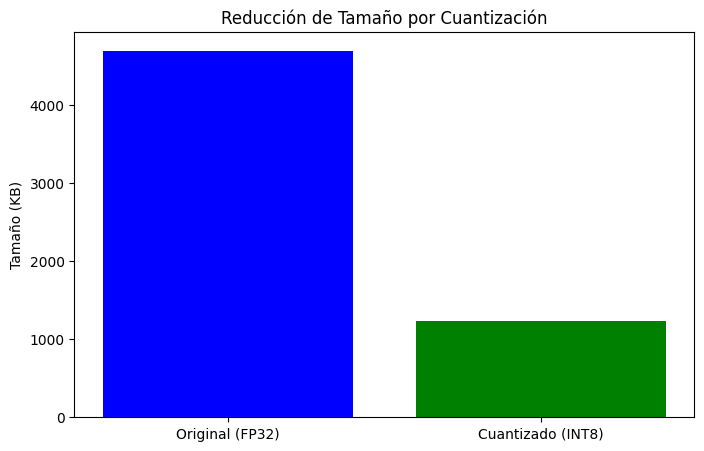

In [19]:
# L5: Optimización de Ancho de Banda (Cuantización)
print("💾 Iniciando L5 (Cuantización)...")

import warnings
# Ignoramos advertencias de depreciación para mantener la salida limpia en la presentación
warnings.filterwarnings("ignore", category=DeprecationWarning)

if os.path.exists(GLOBAL_MODEL_FILE):
    # 1. Cargar modelo original
    original_model = SimpleModel()
    original_model.load_state_dict(torch.load(GLOBAL_MODEL_FILE))
    
    # 2. Cuantizar (Convertir floats de 32-bit a enteros de 8-bit)
    # CONFIGURACIÓN CRÍTICA PARA MAC (Apple Silicon) / Linux
    # PyTorch necesita saber qué "motor" usar para la cuantización.
    # 'qnnpack' funciona bien en CPUs ARM (Mac M1/M2/M3) y x86.
    torch.backends.quantized.engine = 'qnnpack'
    
    quantized_model = torch.quantization.quantize_dynamic(
        original_model, {torch.nn.Linear}, dtype=torch.qint8
    )
    
    # 3. Guardar y comparar tamaños
    QUANTIZED_FILE = "quantized_model.pth"
    torch.save(quantized_model.state_dict(), QUANTIZED_FILE)
    
    size_original = os.path.getsize(GLOBAL_MODEL_FILE) / 1024 # KB
    size_quantized = os.path.getsize(QUANTIZED_FILE) / 1024 # KB
    
    print(f"📦 Tamaño Original: {size_original:.2f} KB")
    print(f"📦 Tamaño Cuantizado: {size_quantized:.2f} KB")
    print(f"🔻 Reducción: {(1 - size_quantized/size_original)*100:.1f}%")
    
    # 4. Verificar Precisión (Breve)
    print("⚖️ Verificando precisión del modelo cuantizado...")
    _, acc_q = evaluate_model(quantized_model, mnist_test)
    print(f"Precisión Modelo Cuantizado: {acc_q*100:.2f}%")
    
    # Graficar
    plt.figure(figsize=(8, 5))
    plt.bar(["Original (FP32)", "Cuantizado (INT8)"], [size_original, size_quantized], color=['blue', 'green'])
    plt.ylabel("Tamaño (KB)")
    plt.title("Reducción de Tamaño por Cuantización")
    plt.show()
    
else:
    print("❌ No se encontró el modelo global de L2 para cuantizar.")